In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from ast import literal_eval

# 그래프 한글 인식 라이브러리 가져오기
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 깨짐 방지

: 

# 데이터 구조 확인

## 데이터 이름, 컬럼명 통일

In [2]:
df_transcript = pd.read_csv('./transcript.csv', index_col=0)
df_customer = pd.read_csv('./profile.csv', index_col=0)
df_promotion = pd.read_csv('./portfolio.csv', index_col=0)
display(df_transcript, df_customer, df_promotion)

,person,event,value,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0
2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0
4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0
...,...,...,...,...
306529,b3a1272bc9904337b331bf348c3e8c17,transaction,{'amount': 1.5899999999999999},714
306530,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,{'amount': 9.53},714
306531,a00058cf10334a308c68e7631c529907,transaction,{'amount': 3.61},714
306532,76ddbd6576844afe811f1a3c0fbb5bec,transaction,{'amount': 3.5300000000000002},714


,gender,age,id,became_member_on,income
0,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN
1,F,55,0610b486422d4921ae7d2bf64640c50b,20170715,112000.0
2,NaN,118,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN
3,F,75,78afa995795e4d85b5d9ceeca43f5fef,20170509,100000.0
4,NaN,118,a03223e636434f42ac4c3df47e8bac43,20170804,NaN
...,...,...,...,...,...
16995,F,45,6d5f3a774f3d4714ab0c092238f3a1d7,20180604,54000.0
16996,M,61,2cb4f97358b841b9a9773a7aa05a9d77,20180713,72000.0
16997,M,49,01d26f638c274aa0b965d24cefe3183f,20170126,73000.0
16998,F,83,9dc1421481194dcd9400aec7c9ae6366,20160307,50000.0


,reward,channels,difficulty,duration,offer_type,id
0,10,"['email', 'mobile', 'social']",10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd
1,10,"['web', 'email', 'mobile', 'social']",10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0
2,0,"['web', 'email', 'mobile']",0,4,informational,3f207df678b143eea3cee63160fa8bed
3,5,"['web', 'email', 'mobile']",5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9
4,5,"['web', 'email']",20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7
5,3,"['web', 'email', 'mobile', 'social']",7,7,discount,2298d6c36e964ae4a3e7e9706d1fb8c2
6,2,"['web', 'email', 'mobile', 'social']",10,10,discount,fafdcd668e3743c1bb461111dcafc2a4
7,0,"['email', 'mobile', 'social']",0,3,informational,5a8bc65990b245e5a138643cd4eb9837
8,5,"['web', 'email', 'mobile', 'social']",5,5,bogo,f19421c1d4aa40978ebb69ca19b0e20d
9,2,"['web', 'email', 'mobile']",10,7,discount,2906b810c7d4411798c6938adc9daaa5


In [3]:
df_transcript = df_transcript.rename(columns={'person': 'person_id'})
df_transcript_origin = df_transcript.copy()

In [4]:
df_promotion = df_promotion.rename(columns = {'reward': 'promotion_reward'})
df_promotion = df_promotion.rename(columns = {'id': 'promotion_id'})

## 테이블 구조 확인

In [5]:
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17000 entries, 0 to 16999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            14825 non-null  object 
 1   age               17000 non-null  int64  
 2   id                17000 non-null  object 
 3   became_member_on  17000 non-null  int64  
 4   income            14825 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 796.9+ KB


In [6]:
df_promotion.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   promotion_reward  10 non-null     int64 
 1   channels          10 non-null     object
 2   difficulty        10 non-null     int64 
 3   duration          10 non-null     int64 
 4   offer_type        10 non-null     object
 5   promotion_id      10 non-null     object
dtypes: int64(3), object(3)
memory usage: 560.0+ bytes


In [7]:
df_transcript.info()

<class 'pandas.core.frame.DataFrame'>
Index: 306534 entries, 0 to 306533
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   person_id  306534 non-null  object
 1   event      306534 non-null  object
 2   value      306534 non-null  object
 3   time       306534 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 11.7+ MB


## 결측치 제거

In [8]:
df_transcript.isna().sum()

person_id    0
event        0
value        0
time         0
dtype: int64

In [9]:
df_customer.isna().sum()

gender              2175
age                    0
id                     0
became_member_on       0
income              2175
dtype: int64

In [10]:
df_promotion.isna().sum()

promotion_reward    0
channels            0
difficulty          0
duration            0
offer_type          0
promotion_id        0
dtype: int64

In [11]:
# gender와 income이 NaN인 데이터는 동일한 데이터
sum(df_customer['gender'].isna() & df_customer['income'].isna())

2175

In [12]:
# NaN 데이터 제거
df_customer = df_customer.dropna(subset=['gender', 'income'], how='all').reset_index(drop=True)
df_customer

,gender,age,id,became_member_on,income
0,F,55,0610b486422d4921ae7d2bf64640c50b,20170715,112000.0
1,F,75,78afa995795e4d85b5d9ceeca43f5fef,20170509,100000.0
2,M,68,e2127556f4f64592b11af22de27a7932,20180426,70000.0
3,M,65,389bc3fa690240e798340f5a15918d5c,20180209,53000.0
4,M,58,2eeac8d8feae4a8cad5a6af0499a211d,20171111,51000.0
...,...,...,...,...,...
14820,F,45,6d5f3a774f3d4714ab0c092238f3a1d7,20180604,54000.0
14821,M,61,2cb4f97358b841b9a9773a7aa05a9d77,20180713,72000.0
14822,M,49,01d26f638c274aa0b965d24cefe3183f,20170126,73000.0
14823,F,83,9dc1421481194dcd9400aec7c9ae6366,20160307,50000.0


In [13]:
# 결측치 제거 확인
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14825 entries, 0 to 14824
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            14825 non-null  object 
 1   age               14825 non-null  int64  
 2   id                14825 non-null  object 
 3   became_member_on  14825 non-null  int64  
 4   income            14825 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 579.2+ KB


## 중복값 제거

In [14]:
# 고객 데이터 중복값 확인 → 중복값 없음
len(df_customer['id'].unique())

14825

In [15]:
df_transcript

,person_id,event,value,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0
2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0
4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0
...,...,...,...,...
306529,b3a1272bc9904337b331bf348c3e8c17,transaction,{'amount': 1.5899999999999999},714
306530,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,{'amount': 9.53},714
306531,a00058cf10334a308c68e7631c529907,transaction,{'amount': 3.61},714
306532,76ddbd6576844afe811f1a3c0fbb5bec,transaction,{'amount': 3.5300000000000002},714


In [16]:
duplicates = df_transcript.duplicated() # 모든 컬럼대상 중복값 확인. 
print(f"중복된 행의 개수: {duplicates.sum()}")

중복된 행의 개수: 397


In [17]:
# 중복값 제거
df_transcript = df_transcript.drop_duplicates() 

In [18]:
df_transcript = df_transcript.reset_index(drop=True)
df_transcript

,person_id,event,value,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0
2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0
4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0
...,...,...,...,...
306132,b3a1272bc9904337b331bf348c3e8c17,transaction,{'amount': 1.5899999999999999},714
306133,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,{'amount': 9.53},714
306134,a00058cf10334a308c68e7631c529907,transaction,{'amount': 3.61},714
306135,76ddbd6576844afe811f1a3c0fbb5bec,transaction,{'amount': 3.5300000000000002},714


In [19]:
df_transcript.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306137 entries, 0 to 306136
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   person_id  306137 non-null  object
 1   event      306137 non-null  object
 2   value      306137 non-null  object
 3   time       306137 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 9.3+ MB


# 데이터 형태 변환

## 딕셔너리 형태 변환

In [20]:
# 함수 정의
def convert_to_dict(val):
    # 이미 딕셔너리라면 그대로 반환
    # isinstance(): 객체가 특정 타입인지 확인
    if isinstance(val, dict):
        return val
    try:
        # 문자열을 딕셔너리 객체로 변환
        return literal_eval(val)
    except (ValueError, SyntaxError):
        # 변환 불가능한 경우 빈 딕셔너리 반환
        return {}

# value 컬럼에 적용
value_dic = df_transcript['value'].apply(convert_to_dict)

In [21]:
# 모든 키값 확인
set().union(*value_dic)

{'amount', 'offer id', 'offer_id', 'reward'}

In [22]:
# # 모든 키값 확인
# set.union(*[set(dic.keys()) for dic in df_transcript['value']])

In [23]:
# 딕셔너리 변환 컬럼
df_transcript['value'] = value_dic

# amount 컬럼 
df_transcript['amount'] = df_transcript['value'].apply(lambda x: x.get('amount'))

# 'offer_id' 추출: 'offer_id'와 'offer id' 두 케이스 모두 대응
df_transcript['offer_id'] = df_transcript['value'].apply(
    lambda x: x.get('offer_id') or x.get('offer id')
)

# 'reward' 추출
df_transcript['reward'] = df_transcript['value'].apply(lambda x: x.get('reward'))

# value 컬럼 삭제
df_transcript = df_transcript.drop('value', axis=1)

In [24]:
df_transcript = df_transcript[['person_id', 'event', 'amount', 'offer_id', 'reward', 'time']]
df_transcript

,person_id,event,amount,offer_id,reward,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,0
1,a03223e636434f42ac4c3df47e8bac43,offer received,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,0
2,e2127556f4f64592b11af22de27a7932,offer received,NaN,2906b810c7d4411798c6938adc9daaa5,NaN,0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,NaN,fafdcd668e3743c1bb461111dcafc2a4,NaN,0
4,68617ca6246f4fbc85e91a2a49552598,offer received,NaN,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,0
...,...,...,...,...,...,...
306132,b3a1272bc9904337b331bf348c3e8c17,transaction,1.59,None,NaN,714
306133,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,9.53,None,NaN,714
306134,a00058cf10334a308c68e7631c529907,transaction,3.61,None,NaN,714
306135,76ddbd6576844afe811f1a3c0fbb5bec,transaction,3.53,None,NaN,714


## channels 리스트 분리해서 컬럼 생성

In [25]:
#channels -> web, email, mobile, social 별 컬럼으로 나누어 0과 1로 표현(ex. web, mobile : web 1 email 0 mobile 1 social 0) 
#대상 채널 리스트 정의
channel_list = ['web', 'email', 'mobile', 'social']

#각 채널별로 컬럼을 만들고 1 또는 0 채우기
for channel in channel_list:
    # 포함 여부 확인
    df_promotion[channel] = df_promotion['channels'].apply(lambda x: 1 if channel in str(x) else 0)

# 채널 컬럼 삭제
df_promotion = df_promotion.drop('channels', axis=1)
df_promotion = df_promotion[['promotion_reward', 'web', 'email', 'mobile', 'social', 'difficulty', 'duration', 'offer_type', 'promotion_id']]
df_promotion

,promotion_reward,web,email,mobile,social,difficulty,duration,offer_type,promotion_id
0,10,0,1,1,1,10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd
1,10,1,1,1,1,10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0
2,0,1,1,1,0,0,4,informational,3f207df678b143eea3cee63160fa8bed
3,5,1,1,1,0,5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9
4,5,1,1,0,0,20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7
5,3,1,1,1,1,7,7,discount,2298d6c36e964ae4a3e7e9706d1fb8c2
6,2,1,1,1,1,10,10,discount,fafdcd668e3743c1bb461111dcafc2a4
7,0,0,1,1,1,0,3,informational,5a8bc65990b245e5a138643cd4eb9837
8,5,1,1,1,1,5,5,bogo,f19421c1d4aa40978ebb69ca19b0e20d
9,2,1,1,1,0,10,7,discount,2906b810c7d4411798c6938adc9daaa5


# 이상치

## 이상치 확인

In [26]:
# 거래 금액 1달러 미만 확인
# df_transcript[df_transcript['amount'] < 1]
df_transcript[df_transcript['amount'].notna() & (df_transcript['amount'] < 1)]

,person_id,event,amount,offer_id,reward,time
12654,02c083884c7d45b39cc68e1314fec56c,transaction,0.83,None,NaN,0
12686,bbeb54e861614fc7b22a8844f72dca6c,transaction,0.22,None,NaN,0
12724,c2c72ce6038644c797208046d1e3498a,transaction,0.75,None,NaN,0
12967,db691240326b44d8bfa7b438c4c41982,transaction,0.05,None,NaN,0
13117,3f7ac208f7e844cab207ceb8e42177ba,transaction,0.23,None,NaN,0
...,...,...,...,...,...,...
306061,60f9f0df41b544a5b243952d8a89541c,transaction,0.64,None,NaN,714
306069,9b84c5f2038e4f638813091d3565a8f0,transaction,0.15,None,NaN,714
306074,791c42c7a024458eae95a5540f69df14,transaction,0.25,None,NaN,714
306088,4b59509988d34c7298119a840c946453,transaction,0.06,None,NaN,714


In [27]:
# 거래 금액 1달러 이상과 NaN인 데이터만
df_transcript = df_transcript[(df_transcript['amount'].isna()) | (df_transcript['amount'] >= 1)]
df_transcript

,person_id,event,amount,offer_id,reward,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,0
1,a03223e636434f42ac4c3df47e8bac43,offer received,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,0
2,e2127556f4f64592b11af22de27a7932,offer received,NaN,2906b810c7d4411798c6938adc9daaa5,NaN,0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,NaN,fafdcd668e3743c1bb461111dcafc2a4,NaN,0
4,68617ca6246f4fbc85e91a2a49552598,offer received,NaN,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,0
...,...,...,...,...,...,...
306132,b3a1272bc9904337b331bf348c3e8c17,transaction,1.59,None,NaN,714
306133,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,9.53,None,NaN,714
306134,a00058cf10334a308c68e7631c529907,transaction,3.61,None,NaN,714
306135,76ddbd6576844afe811f1a3c0fbb5bec,transaction,3.53,None,NaN,714


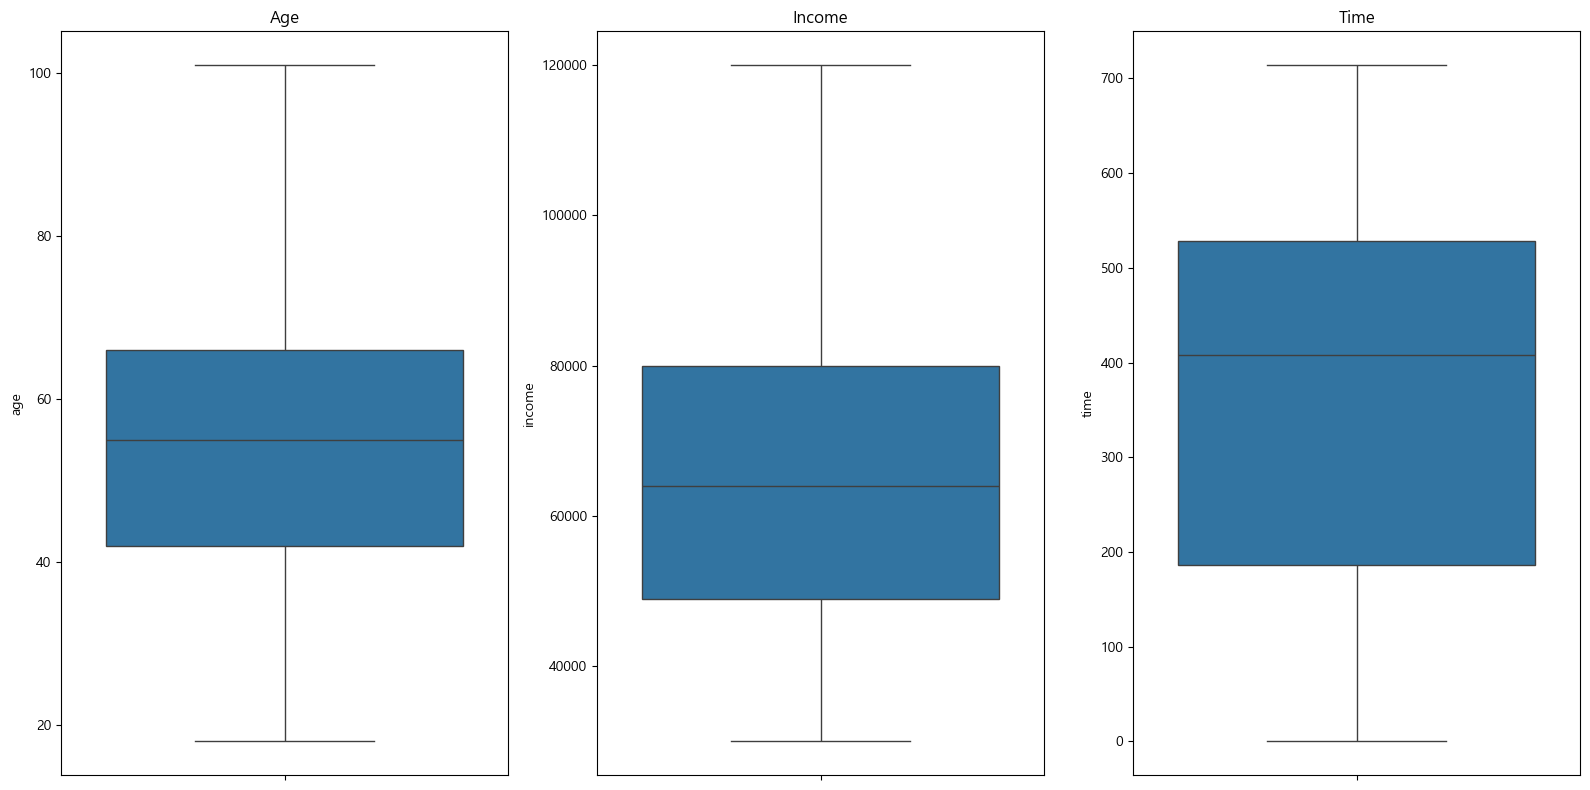

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16,8))

sns.boxplot(df_customer['age'], ax=axes[0])
axes[0].set_title('Age')

sns.boxplot(df_customer['income'], ax=axes[1])
axes[1].set_title('Income')

sns.boxplot(df_transcript['time'], ax=axes[2])
axes[2].set_title('Time')

plt.tight_layout()
plt.show()

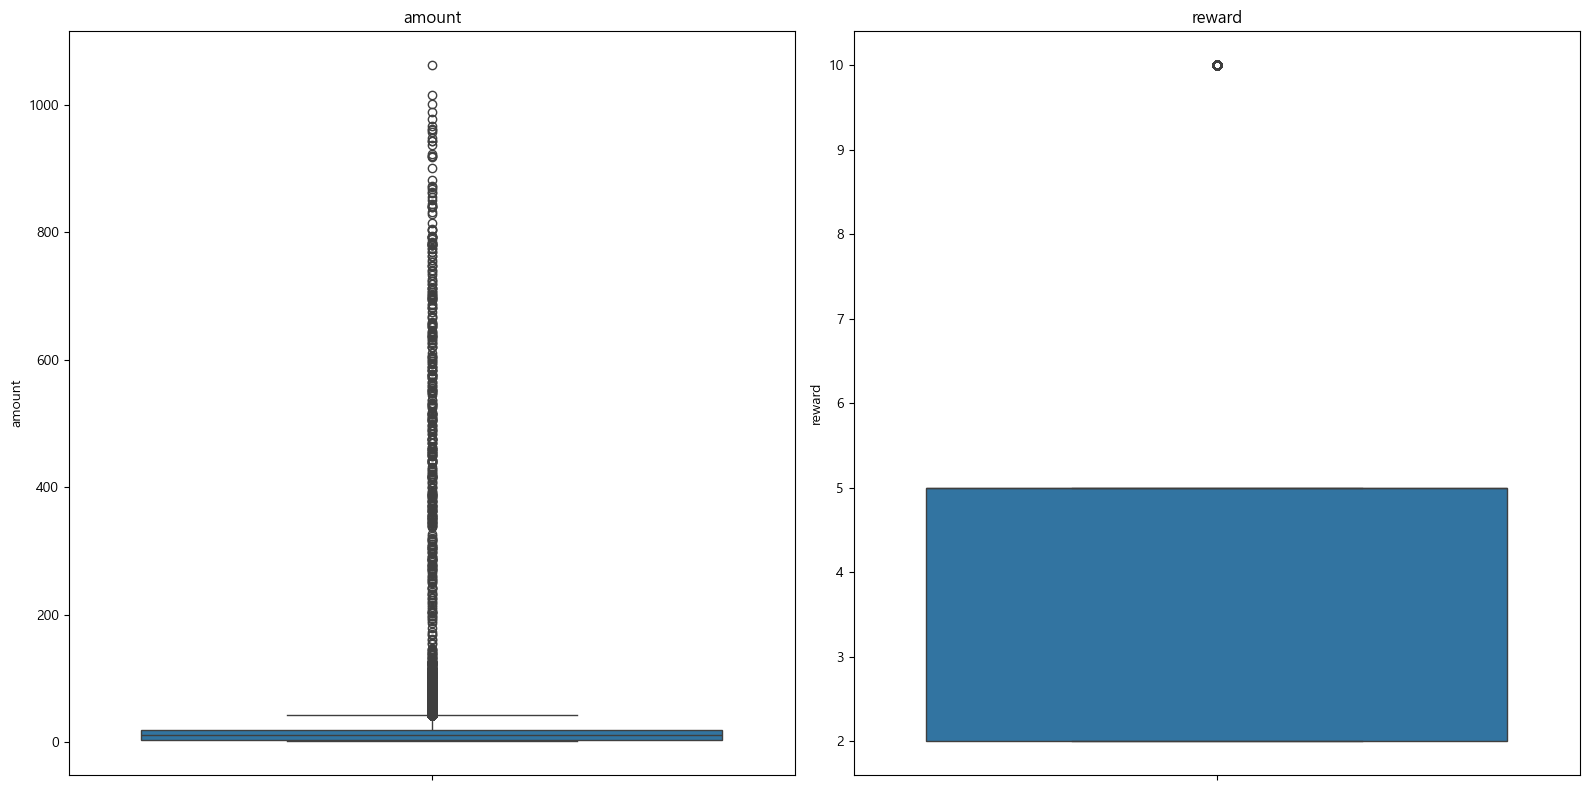

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16,8))

sns.boxplot(df_transcript['amount'], ax=axes[0])
axes[0].set_title('amount')

sns.boxplot(df_transcript['reward'], ax=axes[1])
axes[1].set_title('reward')

plt.tight_layout()
plt.show()

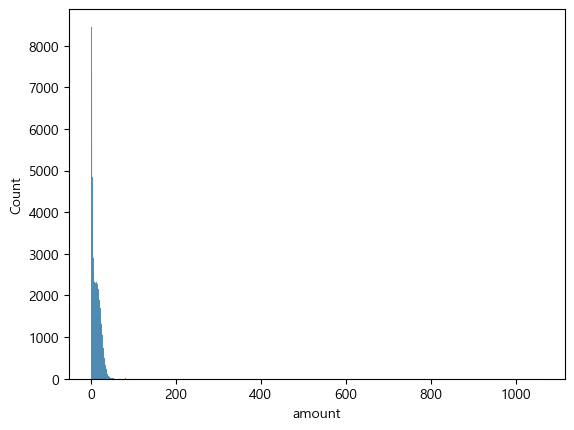

In [30]:
sns.histplot(df_transcript['amount'])
plt.show()

## 로그변환 후 이상치 제거

In [31]:
df_transcript['log_amount'] = np.log1p(df_transcript['amount']) 

C:\Users\user\AppData\Local\Temp\ipykernel_20676\3263945295.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_transcript['log_amount'] = np.log1p(df_transcript['amount'])


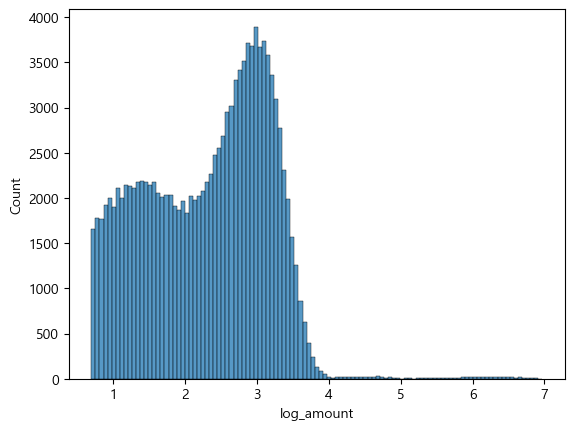

In [32]:
sns.histplot(df_transcript['log_amount'])
plt.show()

In [33]:
# IQR

df1 = df_transcript[['log_amount']]

q3 = df1['log_amount'].quantile(0.75) 
q1 = df1['log_amount'].quantile(0.25)

iqr = q3 - q1
q3, q1, iqr

def is_outlier(df1):
    score = df1['log_amount']
    if score > q3 + (1.5 * iqr) or score < q1 - (1.5 * iqr):
        return '이상치'
    else:
        return '이상치아님'

In [34]:
df_transcript['이상치여부'] = df_transcript.apply(is_outlier, axis = 1)

C:\Users\user\AppData\Local\Temp\ipykernel_20676\2032374540.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_transcript['이상치여부'] = df_transcript.apply(is_outlier, axis = 1)


In [35]:
df_transcript.groupby('이상치여부').size()

이상치여부
이상치         381
이상치아님    293041
dtype: int64

In [36]:
# z-score
df2 = df_transcript[['log_amount']]

df2['zscore'] = StandardScaler().fit_transform(df2)
df2['zscore'].head()

C:\Users\user\AppData\Local\Temp\ipykernel_20676\4099939033.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['zscore'] = StandardScaler().fit_transform(df2)


0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: zscore, dtype: float64

In [37]:
df_transcript['zscore이상치여부'] = df2['zscore'].apply(lambda x: 'z이상치' if ( x < -3 or x > 3) else 'z이상치아님')
df_transcript.groupby('zscore이상치여부', dropna=False).size()

C:\Users\user\AppData\Local\Temp\ipykernel_20676\486969405.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_transcript['zscore이상치여부'] = df2['zscore'].apply(lambda x: 'z이상치' if ( x < -3 or x > 3) else 'z이상치아님')


zscore이상치여부
z이상치         400
z이상치아님    293022
dtype: int64

In [38]:
#iqr - zscore
df_transcript_outlier = df_transcript[(df_transcript['이상치여부'] == '이상치') & (df_transcript['zscore이상치여부'] == 'z이상치')]
df_transcript_outlier

,person_id,event,amount,offer_id,reward,time,log_amount,이상치여부,zscore이상치여부
15540,f367a50b86d049799bbb0eb645ee834c,transaction,195.24,None,NaN,0,5.279338,이상치,z이상치
18053,8a776d222f174aa089866b2725721eec,transaction,448.97,None,NaN,6,6.109181,이상치,z이상치
18417,6b247ba48509456eb57b24f878f313ea,transaction,219.02,None,NaN,12,5.393718,이상치,z이상치
18800,04f1f44632cd409cace939fa62b5fc7a,transaction,628.41,None,NaN,12,6.444783,이상치,z이상치
19097,a12fba072dae4e3aae2e1b4b92b92aa1,transaction,871.51,None,NaN,12,6.771374,이상치,z이상치
...,...,...,...,...,...,...,...,...,...
304058,c92f21de3b1341d7aaf9c5eaae199e0d,transaction,456.62,None,NaN,708,6.126039,이상치,z이상치
304748,76018bc0dfd64ccc8f2e7959bf627ba7,transaction,290.93,None,NaN,708,5.676514,이상치,z이상치
305171,a0f4c1aafeda4398a7afe66c37caf416,transaction,685.07,None,NaN,714,6.530980,이상치,z이상치
305529,692e3eaba5854ad5bbdd51d241647830,transaction,405.04,None,NaN,714,6.006452,이상치,z이상치


In [39]:
idx = df_transcript[(df_transcript['이상치여부'] == '이상치') & (df_transcript['zscore이상치여부'] == 'z이상치')].index
df_transcript.drop(idx , inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_20676\3895363060.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_transcript.drop(idx , inplace=True)


In [40]:
df_transcript.drop(
    columns=['log_amount', '이상치여부', 'zscore이상치여부'],
    inplace=True
)

C:\Users\user\AppData\Local\Temp\ipykernel_20676\1897205722.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_transcript.drop(


In [41]:
df_transcript = df_transcript.reset_index(drop=True)
df_transcript

,person_id,event,amount,offer_id,reward,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,0
1,a03223e636434f42ac4c3df47e8bac43,offer received,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,0
2,e2127556f4f64592b11af22de27a7932,offer received,NaN,2906b810c7d4411798c6938adc9daaa5,NaN,0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,NaN,fafdcd668e3743c1bb461111dcafc2a4,NaN,0
4,68617ca6246f4fbc85e91a2a49552598,offer received,NaN,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,0
...,...,...,...,...,...,...
293036,b3a1272bc9904337b331bf348c3e8c17,transaction,1.59,None,NaN,714
293037,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,9.53,None,NaN,714
293038,a00058cf10334a308c68e7631c529907,transaction,3.61,None,NaN,714
293039,76ddbd6576844afe811f1a3c0fbb5bec,transaction,3.53,None,NaN,714


In [42]:
print(f'원본 데이터 개수: {len(df_transcript_origin)}')
print(f'이상치 제거 후 데이터 개수: {len(df_transcript)}')

원본 데이터 개수: 306534
이상치 제거 후 데이터 개수: 293041


# EDA

## 고객 세분화 진행

### 최신성(R)

In [43]:
df_transcript

,person_id,event,amount,offer_id,reward,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,0
1,a03223e636434f42ac4c3df47e8bac43,offer received,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,0
2,e2127556f4f64592b11af22de27a7932,offer received,NaN,2906b810c7d4411798c6938adc9daaa5,NaN,0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,NaN,fafdcd668e3743c1bb461111dcafc2a4,NaN,0
4,68617ca6246f4fbc85e91a2a49552598,offer received,NaN,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,0
...,...,...,...,...,...,...
293036,b3a1272bc9904337b331bf348c3e8c17,transaction,1.59,None,NaN,714
293037,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,9.53,None,NaN,714
293038,a00058cf10334a308c68e7631c529907,transaction,3.61,None,NaN,714
293039,76ddbd6576844afe811f1a3c0fbb5bec,transaction,3.53,None,NaN,714


In [44]:
df_txn = df_transcript[df_transcript['event'] == 'transaction']

max_time = df_txn['time'].max()
person_last_txn_time = df_txn.groupby('person_id')['time'].max()

df_transcript_rfm = df_transcript.copy()

# 시간 → 일단위로 변경
df_transcript_rfm['diff_last_time'] = (df_transcript_rfm['person_id'].map(max_time - person_last_txn_time)) / 24
df_transcript_rfm

,person_id,event,amount,offer_id,reward,time,diff_last_time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,0,7.50
1,a03223e636434f42ac4c3df47e8bac43,offer received,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,0,18.75
2,e2127556f4f64592b11af22de27a7932,offer received,NaN,2906b810c7d4411798c6938adc9daaa5,NaN,0,8.00
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,NaN,fafdcd668e3743c1bb461111dcafc2a4,NaN,0,NaN
4,68617ca6246f4fbc85e91a2a49552598,offer received,NaN,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,0,NaN
...,...,...,...,...,...,...,...
293036,b3a1272bc9904337b331bf348c3e8c17,transaction,1.59,None,NaN,714,0.00
293037,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,9.53,None,NaN,714,0.00
293038,a00058cf10334a308c68e7631c529907,transaction,3.61,None,NaN,714,0.00
293039,76ddbd6576844afe811f1a3c0fbb5bec,transaction,3.53,None,NaN,714,0.00


### 구매 빈도(F)

In [45]:
df_transcript

,person_id,event,amount,offer_id,reward,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,0
1,a03223e636434f42ac4c3df47e8bac43,offer received,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,0
2,e2127556f4f64592b11af22de27a7932,offer received,NaN,2906b810c7d4411798c6938adc9daaa5,NaN,0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,NaN,fafdcd668e3743c1bb461111dcafc2a4,NaN,0
4,68617ca6246f4fbc85e91a2a49552598,offer received,NaN,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,0
...,...,...,...,...,...,...
293036,b3a1272bc9904337b331bf348c3e8c17,transaction,1.59,None,NaN,714
293037,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,9.53,None,NaN,714
293038,a00058cf10334a308c68e7631c529907,transaction,3.61,None,NaN,714
293039,76ddbd6576844afe811f1a3c0fbb5bec,transaction,3.53,None,NaN,714


In [46]:
txn_cnt = df_transcript.groupby('person_id')['event'].apply(lambda x: (x == 'transaction').sum())
df_transcript_rfm['transaction_cnt'] = df_transcript['person_id'].map(txn_cnt)
df_transcript_rfm

,person_id,event,amount,offer_id,reward,time,diff_last_time,transaction_cnt
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,0,7.50,7
1,a03223e636434f42ac4c3df47e8bac43,offer received,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,0,18.75,2
2,e2127556f4f64592b11af22de27a7932,offer received,NaN,2906b810c7d4411798c6938adc9daaa5,NaN,0,8.00,3
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,NaN,fafdcd668e3743c1bb461111dcafc2a4,NaN,0,NaN,0
4,68617ca6246f4fbc85e91a2a49552598,offer received,NaN,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,0,NaN,0
...,...,...,...,...,...,...,...,...
293036,b3a1272bc9904337b331bf348c3e8c17,transaction,1.59,None,NaN,714,0.00,11
293037,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,9.53,None,NaN,714,0.00,1
293038,a00058cf10334a308c68e7631c529907,transaction,3.61,None,NaN,714,0.00,16
293039,76ddbd6576844afe811f1a3c0fbb5bec,transaction,3.53,None,NaN,714,0.00,10


### 구매 규모(M)(누적 구매)

In [47]:
# 누적 금액
df_transcript_rfm['total_amount'] = df_transcript_rfm.groupby('person_id')['amount'].transform('sum')
df_transcript_rfm

,person_id,event,amount,offer_id,reward,time,diff_last_time,transaction_cnt,total_amount
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,0,7.50,7,159.27
1,a03223e636434f42ac4c3df47e8bac43,offer received,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,0,18.75,2,4.59
2,e2127556f4f64592b11af22de27a7932,offer received,NaN,2906b810c7d4411798c6938adc9daaa5,NaN,0,8.00,3,57.73
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,NaN,fafdcd668e3743c1bb461111dcafc2a4,NaN,0,NaN,0,0.00
4,68617ca6246f4fbc85e91a2a49552598,offer received,NaN,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,0,NaN,0,0.00
...,...,...,...,...,...,...,...,...,...
293036,b3a1272bc9904337b331bf348c3e8c17,transaction,1.59,None,NaN,714,0.00,11,56.08
293037,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,9.53,None,NaN,714,0.00,1,9.53
293038,a00058cf10334a308c68e7631c529907,transaction,3.61,None,NaN,714,0.00,16,59.90
293039,76ddbd6576844afe811f1a3c0fbb5bec,transaction,3.53,None,NaN,714,0.00,10,134.01


### R 구간별 특징 확인
- 프로모션 기간 마지막 접속이 3일 이내 고객이 제일 많으며 마지막 접속일이 7일 내외의 고객 수는 급격히 감소함.
- 최소 결제가 필요한 프로모션의 평균일수 = 7.25일
- 0 ~ 1일
- 1 ~ 3일 (스타벅스 단골 평균 방문일)
- 3 ~ 7일
- 7 ~ 14일 (프로모션을 하나 이상 건너뛴 고객)
- 14일 이상 (장기 미접속)

In [48]:
# df_transcript_rfm.groupby('person_id')['diff_last_time'].mean().reset_index()
customer_diff = df_transcript_rfm[['person_id', 'diff_last_time']].drop_duplicates()
customer_diff

,person_id,diff_last_time
0,78afa995795e4d85b5d9ceeca43f5fef,7.50
1,a03223e636434f42ac4c3df47e8bac43,18.75
2,e2127556f4f64592b11af22de27a7932,8.00
3,8ec6ce2a7e7949b1bf142def7d0e0586,NaN
4,68617ca6246f4fbc85e91a2a49552598,NaN
...,...,...
204928,9fcbff4f8d7241faa4ab8a9d19c8a812,NaN
213470,ebae5093b436466c9fbd097cb7434023,2.25
238887,912b9f623b9e4b4eb99b6dc919f09a93,NaN
243540,3045af4e98794a04a5542d3eac939b1f,NaN


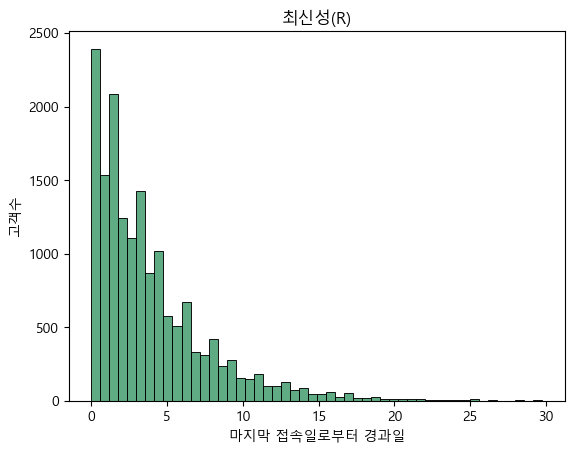

In [49]:
sns.histplot(customer_diff['diff_last_time'], bins=50, color='#2a8f5a')
plt.title('최신성(R)')
plt.xlabel('마지막 접속일로부터 경과일')
plt.ylabel('고객수')
plt.show()

In [50]:
# 지출이 필요한 평균 프로모션 기간
aa = df_promotion[df_promotion['offer_type'] != 'informational']
aa['duration'].sum()/len(aa)

np.float64(7.25)

In [51]:
df_transcript_rfm['R_score'] = np.select(
    [
        df_transcript_rfm['diff_last_time'] <= 1,
        df_transcript_rfm['diff_last_time'] <= 3,
        df_transcript_rfm['diff_last_time'] <= 7,
        df_transcript_rfm['diff_last_time'] <= 14
    ],
    [5, 4, 3, 2], default=1
)
df_transcript_rfm

,person_id,event,amount,offer_id,reward,time,diff_last_time,transaction_cnt,total_amount,R_score
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,0,7.50,7,159.27,2
1,a03223e636434f42ac4c3df47e8bac43,offer received,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,0,18.75,2,4.59,1
2,e2127556f4f64592b11af22de27a7932,offer received,NaN,2906b810c7d4411798c6938adc9daaa5,NaN,0,8.00,3,57.73,2
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,NaN,fafdcd668e3743c1bb461111dcafc2a4,NaN,0,NaN,0,0.00,1
4,68617ca6246f4fbc85e91a2a49552598,offer received,NaN,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,0,NaN,0,0.00,1
...,...,...,...,...,...,...,...,...,...,...
293036,b3a1272bc9904337b331bf348c3e8c17,transaction,1.59,None,NaN,714,0.00,11,56.08,5
293037,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,9.53,None,NaN,714,0.00,1,9.53,5
293038,a00058cf10334a308c68e7631c529907,transaction,3.61,None,NaN,714,0.00,16,59.90,5
293039,76ddbd6576844afe811f1a3c0fbb5bec,transaction,3.53,None,NaN,714,0.00,10,134.01,5


In [52]:
# 각 점수별 고객 비율
df_transcript_rfm['R_score'].value_counts(normalize=True) * 100

R_score
4    32.158640
3    28.090608
5    26.658386
2     9.977102
1     3.115264
Name: proportion, dtype: float64

### F 구간별 특징 확인
- 고객별 구매 건수가 4~10회 구간에 대다수의 고객이 밀집
- 0 ~ 3회
- 3 ~ 5회
- 5 ~ 10회
- 10 ~ 15 회 기준으로 나눔

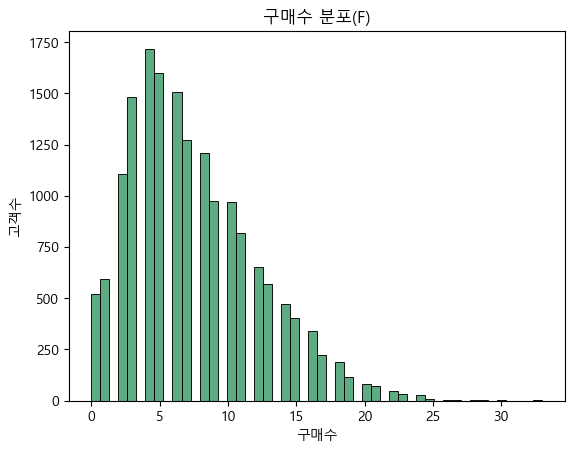

In [53]:
sns.histplot(df_transcript_rfm.groupby('person_id')['transaction_cnt'].mean(), bins=50, color='#2a8f5a')
plt.title('구매수 분포(F)')
plt.xlabel('구매수')
plt.ylabel('고객수')
plt.show()

In [54]:
df_transcript_rfm['F_score'] = np.select(
    [
        df_transcript_rfm['transaction_cnt'] <= 3,
        df_transcript_rfm['transaction_cnt'] <= 5,
        df_transcript_rfm['transaction_cnt'] <= 10,
        df_transcript_rfm['transaction_cnt'] <= 15
    ],
    [1, 2, 3, 4], default=5
)
df_transcript_rfm

,person_id,event,amount,offer_id,reward,time,diff_last_time,transaction_cnt,total_amount,R_score,F_score
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,0,7.50,7,159.27,2,3
1,a03223e636434f42ac4c3df47e8bac43,offer received,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,0,18.75,2,4.59,1,1
2,e2127556f4f64592b11af22de27a7932,offer received,NaN,2906b810c7d4411798c6938adc9daaa5,NaN,0,8.00,3,57.73,2,1
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,NaN,fafdcd668e3743c1bb461111dcafc2a4,NaN,0,NaN,0,0.00,1,1
4,68617ca6246f4fbc85e91a2a49552598,offer received,NaN,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,0,NaN,0,0.00,1,1
...,...,...,...,...,...,...,...,...,...,...,...
293036,b3a1272bc9904337b331bf348c3e8c17,transaction,1.59,None,NaN,714,0.00,11,56.08,5,4
293037,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,9.53,None,NaN,714,0.00,1,9.53,5,1
293038,a00058cf10334a308c68e7631c529907,transaction,3.61,None,NaN,714,0.00,16,59.90,5,5
293039,76ddbd6576844afe811f1a3c0fbb5bec,transaction,3.53,None,NaN,714,0.00,10,134.01,5,3


In [55]:
# 각 점수별 고객 비율
df_transcript_rfm['F_score'].value_counts(normalize=True) * 100

F_score
3    36.367607
4    23.832501
2    15.076047
1    12.822438
5    11.901406
Name: proportion, dtype: float64

### M 구간별 특징 확인
- 고객별 총 구매 금액이 0 ~ 50 달러 부근에 밀집되어 있다.
- 인원이 밀집된 구간을 조금 더 촘촘하게 나눌 필요가 있다.
- 0 ~ 25 (초반 밀집)
- 25 ~ 60 
- 60 ~ 120 (완만한 하강곡선 시작 부분)
- 120 ~ 200 (다시 인원 감소 기울기 증가)
- 200 달러 이상 (소수의 고액)

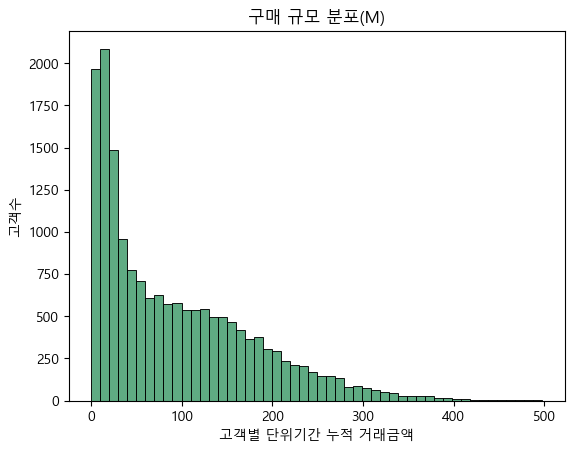

In [56]:
sns.histplot(df_transcript_rfm.groupby('person_id')['total_amount'].mean(), bins=50, color='#2a8f5a')
plt.title('구매 규모 분포(M)')
plt.xlabel('고객별 단위기간 누적 거래금액')
plt.ylabel('고객수')
plt.show()

In [57]:
df_transcript_rfm['M_score'] = np.select(
    [
        df_transcript_rfm['total_amount'] <= 25,
        df_transcript_rfm['total_amount'] <= 60,
        df_transcript_rfm['total_amount'] <= 120,
        df_transcript_rfm['total_amount'] <= 200
    ],
    [1, 2, 3, 4], default=5
)
df_transcript_rfm

,person_id,event,amount,offer_id,reward,time,diff_last_time,transaction_cnt,total_amount,R_score,F_score,M_score
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,0,7.50,7,159.27,2,3,4
1,a03223e636434f42ac4c3df47e8bac43,offer received,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,0,18.75,2,4.59,1,1,1
2,e2127556f4f64592b11af22de27a7932,offer received,NaN,2906b810c7d4411798c6938adc9daaa5,NaN,0,8.00,3,57.73,2,1,2
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,NaN,fafdcd668e3743c1bb461111dcafc2a4,NaN,0,NaN,0,0.00,1,1,1
4,68617ca6246f4fbc85e91a2a49552598,offer received,NaN,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,0,NaN,0,0.00,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
293036,b3a1272bc9904337b331bf348c3e8c17,transaction,1.59,None,NaN,714,0.00,11,56.08,5,4,2
293037,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,9.53,None,NaN,714,0.00,1,9.53,5,1,1
293038,a00058cf10334a308c68e7631c529907,transaction,3.61,None,NaN,714,0.00,16,59.90,5,5,2
293039,76ddbd6576844afe811f1a3c0fbb5bec,transaction,3.53,None,NaN,714,0.00,10,134.01,5,3,4


In [58]:
# 각 점수별 고객 비율
df_transcript_rfm['M_score'].value_counts(normalize=True) * 100

M_score
4    24.300695
3    20.830873
1    18.974819
5    18.053105
2    17.840507
Name: proportion, dtype: float64

### RFM 최종 점수 산출
- VVIP: 13 ~ 15점
- VIP: 11 ~ 12점
- 충성고객: 8 ~ 10점
- 잠재고객: 5 ~ 7점
- 위험고객: 4점 이하

In [59]:
df_transcript_rfm['RFM_score'] = df_transcript_rfm['R_score'] + df_transcript_rfm['F_score'] + df_transcript_rfm['M_score']
df_transcript_rfm

,person_id,event,amount,offer_id,reward,time,diff_last_time,transaction_cnt,total_amount,R_score,F_score,M_score,RFM_score
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,0,7.50,7,159.27,2,3,4,9
1,a03223e636434f42ac4c3df47e8bac43,offer received,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,0,18.75,2,4.59,1,1,1,3
2,e2127556f4f64592b11af22de27a7932,offer received,NaN,2906b810c7d4411798c6938adc9daaa5,NaN,0,8.00,3,57.73,2,1,2,5
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,NaN,fafdcd668e3743c1bb461111dcafc2a4,NaN,0,NaN,0,0.00,1,1,1,3
4,68617ca6246f4fbc85e91a2a49552598,offer received,NaN,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,0,NaN,0,0.00,1,1,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
293036,b3a1272bc9904337b331bf348c3e8c17,transaction,1.59,None,NaN,714,0.00,11,56.08,5,4,2,11
293037,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,9.53,None,NaN,714,0.00,1,9.53,5,1,1,7
293038,a00058cf10334a308c68e7631c529907,transaction,3.61,None,NaN,714,0.00,16,59.90,5,5,2,12
293039,76ddbd6576844afe811f1a3c0fbb5bec,transaction,3.53,None,NaN,714,0.00,10,134.01,5,3,4,12


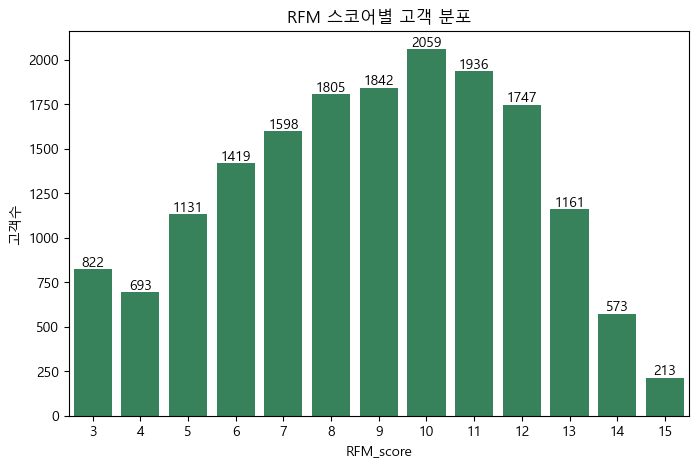

In [60]:
# RFM_score별 고객 수 집계
temp = df_transcript_rfm.groupby('person_id')['RFM_score'].max().reset_index()
temp = (
    temp
    .groupby('RFM_score')['person_id']
    .count()
    .reset_index(name='customer_cnt')
)

# 그래프 그리기
fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(
    data=temp,
    x='RFM_score',
    y='customer_cnt',
    color='#2a8f5a',
    ax=ax
)

# 막대 끝 위쪽에 고객 수 표시
for p in ax.patches:
    height = p.get_height()           # 막대 높이
    ax.text(
        x=p.get_x() + p.get_width()/2,  # 막대 중심
        y=height,                        # 막대 끝
        s=int(height),                   # 표시할 텍스트
        ha='center', va='bottom',        # 가운데 정렬, 아래쪽 기준
        fontsize=10
    )

plt.title('RFM 스코어별 고객 분포')
plt.ylabel('고객수')
plt.show()

In [61]:
df_transcript_rfm['RFM_group'] = np.select(
    [
        df_transcript_rfm['RFM_score'] >= 14,
        df_transcript_rfm['RFM_score'] >= 11,
        df_transcript_rfm['RFM_score'] >= 8,
        df_transcript_rfm['RFM_score'] >= 5
    ],
    ['VVIP', 'VIP', '충성고객', '잠재고객'],  # 조건 순서대로 라벨
    default='우려고객'
)
df_transcript_rfm

,person_id,event,amount,offer_id,reward,time,diff_last_time,transaction_cnt,total_amount,R_score,F_score,M_score,RFM_score,RFM_group
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,0,7.50,7,159.27,2,3,4,9,충성고객
1,a03223e636434f42ac4c3df47e8bac43,offer received,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,0,18.75,2,4.59,1,1,1,3,우려고객
2,e2127556f4f64592b11af22de27a7932,offer received,NaN,2906b810c7d4411798c6938adc9daaa5,NaN,0,8.00,3,57.73,2,1,2,5,잠재고객
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,NaN,fafdcd668e3743c1bb461111dcafc2a4,NaN,0,NaN,0,0.00,1,1,1,3,우려고객
4,68617ca6246f4fbc85e91a2a49552598,offer received,NaN,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,0,NaN,0,0.00,1,1,1,3,우려고객
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
293036,b3a1272bc9904337b331bf348c3e8c17,transaction,1.59,None,NaN,714,0.00,11,56.08,5,4,2,11,VIP
293037,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,9.53,None,NaN,714,0.00,1,9.53,5,1,1,7,잠재고객
293038,a00058cf10334a308c68e7631c529907,transaction,3.61,None,NaN,714,0.00,16,59.90,5,5,2,12,VIP
293039,76ddbd6576844afe811f1a3c0fbb5bec,transaction,3.53,None,NaN,714,0.00,10,134.01,5,3,4,12,VIP


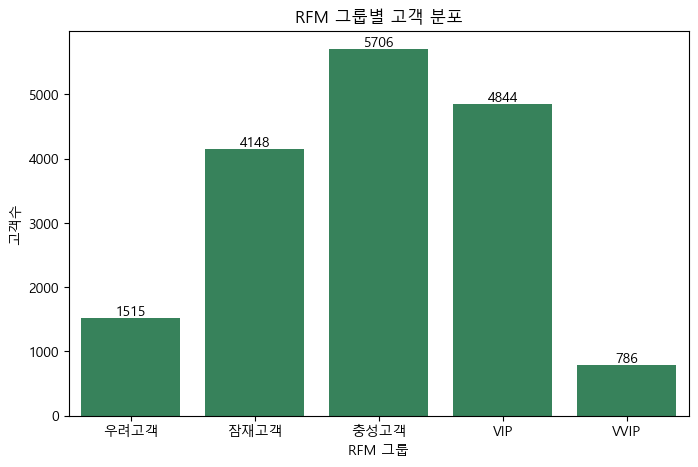

In [62]:
# 고객 수 집계
temp = (
    df_transcript_rfm
    .groupby('RFM_group')['person_id']
    .nunique() # 고유 카운트
    .reset_index(name='customer_cnt')
)

# 원하는 순서 지정
order = ['우려고객', '잠재고객', '충성고객', 'VIP', 'VVIP']
temp['RFM_group'] = pd.Categorical(
    temp['RFM_group'],
    categories=order,
    ordered=True
)

# 그래프 그리기
fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(
    data=temp,
    x='RFM_group',
    y='customer_cnt',
    color='#2a8f5a',
    order=order,
    ax=ax
)

# 막대 위쪽에 고객 수 표시
for p in ax.patches:
    height = p.get_height()           # 막대 높이
    ax.text(
        x=p.get_x() + p.get_width()/2,  # 막대 중심
        y=height,                        # 막대 끝
        s=int(height),                   # 표시할 텍스트
        ha='center', va='bottom',        # 가운데 정렬, 아래쪽 기준
        fontsize=10
    )

plt.title('RFM 그룹별 고객 분포')
plt.xlabel('RFM 그룹')
plt.ylabel('고객수')
plt.show()

# transactions에 offer_id 부여

### transactions 중 어떤 promotion의 영향을 받아 일어난 매출인지 구분해주기 위해 offer_id를 부여해주는 과정입니다.

In [63]:
def phase1_generate_offer_id(df_transcript):
    df = df_transcript.sort_values(['person_id', 'time']).copy()
    
    # 임시 컬럼 생성
    df['assigned_id'] = np.nan
    df['match_source'] = np.nan
    df['viewed_time'] = np.nan  

    for p_id, group in df.groupby('person_id'):
        transactions = group[group['event'] == 'transaction']
        completed = group[group['event'] == 'offer completed']
        viewed = group[group['event'] == 'offer viewed']
        
        for idx, t_row in transactions.iterrows():
            t_time = t_row['time']
            
            # [조건 1] Completed 시간 일치
            exact_comp = completed[completed['time'] == t_time]
            if not exact_comp.empty:
                last_comp = exact_comp.iloc[-1]
                df.at[idx, 'assigned_id'] = last_comp['offer_id']
                df.at[idx, 'match_source'] = 'completed'
                # completed인 경우, 해당 오퍼를 가장 최근에 본 시간을 찾아 기록
                last_view = viewed[viewed['time'] <= t_time].sort_values('time', ascending=False)
                if not last_view.empty:
                    df.at[idx, 'viewed_time'] = last_view.iloc[0]['time']
                continue
            
            # [조건 2] 직전 Viewed 존재
            past_views = viewed[viewed['time'] <= t_time].sort_values('time', ascending=False)
            if not past_views.empty:
                df.at[idx, 'assigned_id'] = past_views.iloc[0]['offer_id']
                df.at[idx, 'match_source'] = 'viewed'
                # [중요] offer_viewed 행의 'time' 값을 viewed_time 컬럼에 저장
                df.at[idx, 'viewed_time'] = past_views.iloc[0]['time'] 
    
    df['offer_id'] = df['offer_id'].fillna(df['assigned_id'])
    df = df.drop(columns=['assigned_id'])
    
    return df

# 1단계 실행(rfm 점수 추가한 데이터프레임으로 진행)
df_step1 = phase1_generate_offer_id(df_transcript_rfm)

C:\Users\user\AppData\Local\Temp\ipykernel_20676\3956403864.py:32: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '5a8bc65990b245e5a138643cd4eb9837' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.at[idx, 'assigned_id'] = past_views.iloc[0]['offer_id']
C:\Users\user\AppData\Local\Temp\ipykernel_20676\3956403864.py:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'viewed' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.at[idx, 'match_source'] = 'viewed'


In [64]:
# promotion_id를 키로, difficulty를 포함한 스펙을 밸류로
promo_lookup = df_promotion.set_index('promotion_id').to_dict('index')

In [65]:

#completed와 time이 일치한 transactions 중 해당 id의 difficulty를 넘어서지 못한 케이스가 있는지 확인(그 전에 있던 결제와 합쳐져 difficulty를 넘어 offer를 complete한 것으로 봤습니다.) 
def check_insufficient_amount_fast(df_step1, df_promotion):
    # 1. 비교를 위한 difficulty 정보 미리 준비
    promo_info = df_promotion[['promotion_id', 'difficulty']]
    
    # 2. completed와 transaction만 분리
    comp = df_step1[df_step1['event'] == 'offer completed'][['person_id', 'time', 'offer_id']]
    trans = df_step1[df_step1['event'] == 'transaction'][['person_id', 'time', 'amount']]
    
    # 3. [핵심] 병합(Merge)을 통해 동일인물 & 동일시간 짝을 한 번에 찾기
    merged = pd.merge(comp, trans, on=['person_id', 'time'], how='inner')
    
    # 4. 난이도(difficulty) 정보 붙이기
    merged = pd.merge(merged, promo_info, left_on='offer_id', right_on='promotion_id', how='left')
    
    # 5. 한 번에 계산 (Vectorized Operation)
    insufficient = merged[merged['amount'] < merged['difficulty']].copy()
    insufficient['gap'] = insufficient['difficulty'] - insufficient['amount']
    
    return insufficient

# 실행 
insufficient_df = check_insufficient_amount_fast(df_step1, df_promotion)
print(f"발견된 부족 케이스: {len(insufficient_df)}건")

발견된 부족 케이스: 4507건


In [66]:
# 1. 4,621건 중 첫 번째 샘플 ID 추출
sample_case = insufficient_df.iloc[0]
sample_id = sample_case['person_id']
target_offer_id = sample_case['offer_id']

print(f" 분석 대상 ID: {sample_id}")
print(f" 타겟 오퍼 ID: {target_offer_id} (난이도: {sample_case['difficulty']})")
print(f" 완료 시점 결제액: {sample_case['amount']} (부족분: {sample_case['gap']})")
print("-" * 50)

# 2. 해당 사용자의 전체 히스토리 추출 (시간순)
# df_step1이나 1단계가 완료된 데이터프레임을 사용하세요.
sample_history = df_step1[df_step1['person_id'] == sample_id].sort_values('time')

# 3. 주요 컬럼만 보기 좋게 출력
display(sample_history[['time', 'event', 'offer_id', 'amount']])

 분석 대상 ID: 003d66b6608740288d6cc97a6903f4f0
 타겟 오퍼 ID: fafdcd668e3743c1bb461111dcafc2a4 (난이도: 10)
 완료 시점 결제액: 3.66 (부족분: 6.34)
--------------------------------------------------


,time,event,offer_id,amount
2652,0,offer received,5a8bc65990b245e5a138643cd4eb9837,NaN
26612,36,offer viewed,5a8bc65990b245e5a138643cd4eb9837,NaN
35257,72,transaction,5a8bc65990b245e5a138643cd4eb9837,2.07
53472,168,offer received,fafdcd668e3743c1bb461111dcafc2a4,NaN
79541,204,transaction,5a8bc65990b245e5a138643cd4eb9837,1.48
100793,300,offer viewed,fafdcd668e3743c1bb461111dcafc2a4,NaN
105302,330,transaction,fafdcd668e3743c1bb461111dcafc2a4,2.29
108326,336,offer received,3f207df678b143eea3cee63160fa8bed,NaN
130895,360,transaction,fafdcd668e3743c1bb461111dcafc2a4,2.19
134867,372,offer viewed,3f207df678b143eea3cee63160fa8bed,NaN


In [67]:
def phase2_confirm_offer_id(df_step1, df_promotion):
    df = df_step1.copy()
    # 1. 초기화: 기본값 설정
    df['purchase_type'] = '비프로모션매출(organic)'
    processed_indices = set()
    # 프로모션 정보 딕셔너리 (유효기간 체크용)
    promo_lookup = df_promotion.set_index('promotion_id').to_dict('index')
    for p_id, group in df.groupby('person_id'):
        completed_events = group[group['event'] == 'offer completed'].sort_values('time')
        transactions = group[group['event'] == 'transaction'].sort_values('time')
        # --- [Step A] Completed 오퍼 처리 (백트래킹 포함) ---
        for _, c_row in completed_events.iterrows():
            c_time, c_offer_id = c_row['time'], c_row['offer_id']
            specs = promo_lookup.get(c_offer_id)
            if not specs: continue
            same_time_trans = transactions[transactions['time'] == c_time]
            if not same_time_trans.empty:
                current_idx = same_time_trans.index[0]
                total_amount = df.at[current_idx, 'amount']
                match_indices = [current_idx]
                # 난이도 충족을 위한 백트래킹
                if total_amount < specs['difficulty']:
                    past_trans = transactions[transactions['time'] < c_time].sort_values('time', ascending=False)
                    for p_idx, p_row in past_trans.iterrows():
                        if total_amount >= specs['difficulty']: break
                        if p_idx not in processed_indices:
                            total_amount += p_row['amount']
                            match_indices.append(p_idx)
                # 매칭된 결제에 ID 부여 및 라벨링
                for m_idx in match_indices:
                    df.at[m_idx, 'offer_id'] = c_offer_id
                    df.at[m_idx, 'purchase_type'] = '직접기여매출(sell completed)'
                    processed_indices.add(m_idx)
        # --- [Step B] 남은 결제 처리 (viewed_time 결측치 방어) ---
        remaining_trans = transactions[~transactions.index.isin(processed_indices)]
        for t_idx, t_row in remaining_trans.iterrows():
            t_id, v_time = t_row['offer_id'], t_row['viewed_time']
            # [방어] ID와 본 시간(viewed_time)이 둘 다 있을 때만 유효기간 계산
            if pd.notna(t_id) and pd.notna(v_time):
                spec = promo_lookup.get(t_id)
                if spec:
                    is_time_ok = v_time <= t_row['time'] <= v_time + (spec['duration'] * 24)
                    if is_time_ok:
                        df.at[t_idx, 'purchase_type'] = "간접기여매출(viewed only)"
                        processed_indices.add(t_idx)
                        continue
            # [클리닝] 조건 미달 시 Organic 강등 및 정보 삭제
            df.at[t_idx, 'purchase_type'] = '비프로모션매출(organic)'
            df.at[t_idx, 'offer_id'] = np.nan # ID를 지워야 나중에 Merge할 때 리워드가 안 붙음
    return df

In [68]:
# 1. 2단계 실행
df_final = phase2_confirm_offer_id(df_step1, df_promotion)

In [69]:
# 2. 최종 Merge (확정된 ID를 기준으로 상세 정보 결합)
df_final = pd.merge(df_final, df_promotion, left_on='offer_id', right_on='promotion_id', how='left')

In [70]:
# 4. 결과 확인
print(df_final['purchase_type'].value_counts())

purchase_type
비프로모션매출(organic)          188564
간접기여매출(viewed only)        66874
직접기여매출(sell completed)     37603
Name: count, dtype: int64


In [71]:
df_final[['purchase_type', 'offer_type']]

,purchase_type,offer_type
0,비프로모션매출(organic),informational
1,비프로모션매출(organic),informational
2,간접기여매출(viewed only),informational
3,비프로모션매출(organic),informational
4,비프로모션매출(organic),informational
...,...,...
293036,직접기여매출(sell completed),discount
293037,비프로모션매출(organic),discount
293038,비프로모션매출(organic),discount
293039,간접기여매출(viewed only),discount


In [72]:
# 'organic'으로 분류된 결제들 중, 사실은 오퍼 기간(Duration)을 아깝게 넘긴 것들이 많은지 확인
df_check = df_final[df_final['purchase_type'] == 'organic'].copy()

# 오퍼를 보긴 했는데 기간만 지난 케이스가 있는지 체크
late_buyers = df_check[df_check['viewed_time'].notna()]
print(f"오퍼를 보긴 했지만 기간이 지나 organic이 된 건수: {len(late_buyers)}건")

오퍼를 보긴 했지만 기간이 지나 organic이 된 건수: 0건


In [73]:
#customer라 합침
# 1. 고객 데이터의 'id'를 'person_id'로 미리 바꿉니다.
df_customer_renamed = df_customer.rename(columns={'id': 'person_id'})

In [74]:
# 2. 이제 같은 이름('person_id')을 기준으로 합칩니다.
# 이렇게 하면 Pandas가 두 컬럼을 하나로 합쳐버려서 중복 데이터가 안 생깁니다!
df_total = pd.merge(df_final, df_customer_renamed, on='person_id', how='left')

In [75]:
# 하나의 offer_id에 하나의 offer_type만 문제없이 되어있는지 확인
check = df_total.groupby('offer_id')['offer_type'].nunique()
check

offer_id
0b1e1539f2cc45b7b9fa7c272da2e1d7    1
2298d6c36e964ae4a3e7e9706d1fb8c2    1
2906b810c7d4411798c6938adc9daaa5    1
3f207df678b143eea3cee63160fa8bed    1
4d5c57ea9a6940dd891ad53e9dbe8da0    1
5a8bc65990b245e5a138643cd4eb9837    1
9b98b8c7a33c4b65b9aebfe6a799e6d9    1
ae264e3637204a6fb9bb56bc8210ddfd    1
f19421c1d4aa40978ebb69ca19b0e20d    1
fafdcd668e3743c1bb461111dcafc2a4    1
Name: offer_type, dtype: int64

## csv로 파일 저장

In [76]:
df_total.to_csv('./starbucks_merged_real_final.csv')

In [77]:
df_transcript_rfm.to_csv('./event_log.csv')
df_customer.to_csv('./customer.csv')
df_promotion.to_csv('./promotion.csv')

In [78]:
df_total.purchase_type.unique()

array(['비프로모션매출(organic)', '간접기여매출(viewed only)',
       '직접기여매출(sell completed)'], dtype=object)

## 고객 그룹별 인사이트

- 그룹별 완료율

In [79]:
df_total

,person_id,event,amount,offer_id,reward,time,diff_last_time,transaction_cnt,total_amount,R_score,...,mobile,social,difficulty,duration,offer_type,promotion_id,gender,age,became_member_on,income
0,0009655768c64bdeb2e877511632db8f,offer received,NaN,5a8bc65990b245e5a138643cd4eb9837,NaN,168,0.75,8,127.60,5,...,1.0,1.0,0.0,3.0,informational,5a8bc65990b245e5a138643cd4eb9837,M,33.0,20170421.0,72000.0
1,0009655768c64bdeb2e877511632db8f,offer viewed,NaN,5a8bc65990b245e5a138643cd4eb9837,NaN,192,0.75,8,127.60,5,...,1.0,1.0,0.0,3.0,informational,5a8bc65990b245e5a138643cd4eb9837,M,33.0,20170421.0,72000.0
2,0009655768c64bdeb2e877511632db8f,transaction,22.16,5a8bc65990b245e5a138643cd4eb9837,NaN,228,0.75,8,127.60,5,...,1.0,1.0,0.0,3.0,informational,5a8bc65990b245e5a138643cd4eb9837,M,33.0,20170421.0,72000.0
3,0009655768c64bdeb2e877511632db8f,offer received,NaN,3f207df678b143eea3cee63160fa8bed,NaN,336,0.75,8,127.60,5,...,1.0,0.0,0.0,4.0,informational,3f207df678b143eea3cee63160fa8bed,M,33.0,20170421.0,72000.0
4,0009655768c64bdeb2e877511632db8f,offer viewed,NaN,3f207df678b143eea3cee63160fa8bed,NaN,372,0.75,8,127.60,5,...,1.0,0.0,0.0,4.0,informational,3f207df678b143eea3cee63160fa8bed,M,33.0,20170421.0,72000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
293036,ffff82501cea40309d5fdd7edcca4a07,transaction,14.23,2906b810c7d4411798c6938adc9daaa5,NaN,576,2.75,15,226.07,4,...,1.0,0.0,10.0,7.0,discount,2906b810c7d4411798c6938adc9daaa5,F,45.0,20161125.0,62000.0
293037,ffff82501cea40309d5fdd7edcca4a07,offer completed,NaN,2906b810c7d4411798c6938adc9daaa5,2.0,576,2.75,15,226.07,4,...,1.0,0.0,10.0,7.0,discount,2906b810c7d4411798c6938adc9daaa5,F,45.0,20161125.0,62000.0
293038,ffff82501cea40309d5fdd7edcca4a07,offer viewed,NaN,2906b810c7d4411798c6938adc9daaa5,NaN,582,2.75,15,226.07,4,...,1.0,0.0,10.0,7.0,discount,2906b810c7d4411798c6938adc9daaa5,F,45.0,20161125.0,62000.0
293039,ffff82501cea40309d5fdd7edcca4a07,transaction,10.12,2906b810c7d4411798c6938adc9daaa5,NaN,606,2.75,15,226.07,4,...,1.0,0.0,10.0,7.0,discount,2906b810c7d4411798c6938adc9daaa5,F,45.0,20161125.0,62000.0


In [80]:
promo_status = df_total.groupby(['person_id', 'offer_id'])['event'].apply(list).reset_index()

# person_id별 RFM_group
rfm_group_info = df_total[['person_id', 'RFM_group']].drop_duplicates()

# offer_id별 offer_type
offer_info = df_total[['offer_id', 'offer_type']].drop_duplicates()

# merge
promo_status = promo_status.merge(rfm_group_info, on='person_id', how='left')
promo_status = promo_status.merge(offer_info, on='offer_id', how='left')

# offer_type별 완료 조건
def is_completed(row):
    events = row['event']
    offer_type = row['offer_type']
    
    if offer_type == 'informational':
        return ('offer received' in events) and ('offer viewed' in events)
    else:
        return ('offer received' in events) and ('offer completed' in events)

promo_status['completed'] = promo_status.apply(is_completed, axis=1)
promo_status

,person_id,offer_id,event,RFM_group,offer_type,completed
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,"[offer received, transaction, offer completed]",VIP,discount,True
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,"[offer received, offer viewed]",VIP,informational,True
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,"[offer received, offer viewed, transaction]",VIP,informational,True
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,"[offer received, transaction, offer completed,...",VIP,bogo,True
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,"[offer received, transaction, offer completed,...",VIP,discount,True
...,...,...,...,...,...,...
63283,fffad4f4828548d1b5583907f2e9906b,f19421c1d4aa40978ebb69ca19b0e20d,"[offer received, offer viewed, transaction, of...",VIP,bogo,True
63284,ffff82501cea40309d5fdd7edcca4a07,0b1e1539f2cc45b7b9fa7c272da2e1d7,"[offer received, offer viewed, transaction, of...",VIP,discount,True
63285,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,"[offer received, offer viewed, transaction, of...",VIP,discount,True
63286,ffff82501cea40309d5fdd7edcca4a07,9b98b8c7a33c4b65b9aebfe6a799e6d9,"[offer received, transaction, offer completed,...",VIP,bogo,True


In [81]:
# RFM_group별 완료율 계산
rfm_completion = (
    promo_status
    .groupby(['RFM_group', 'offer_type'])
    .agg(
        total_cnt=('completed', 'count'),
        completed_cnt=('completed', 'sum')
    )
    .reset_index()
)

rfm_completion['completion_rate'] = (
    rfm_completion['completed_cnt'] / rfm_completion['total_cnt']
)

# offer_type 순서
offer_order = ['informational', 'discount', 'bogo']

# RFM_group 순서
rfm_order = ['VVIP', 'VIP', '충성고객', '잠재고객', '우려고객']

# Categorical로 순서 지정
rfm_completion['RFM_group'] = pd.Categorical(
    rfm_completion['RFM_group'],
    categories=rfm_order,
    ordered=True
)

rfm_completion['offer_type'] = pd.Categorical(
    rfm_completion['offer_type'],
    categories=offer_order,
    ordered=True
)

# RFM_group → offer_type 순으로 정렬
rfm_completion = rfm_completion.sort_values(['RFM_group', 'offer_type'])
rfm_completion['completion_rate_pct'] = rfm_completion['completion_rate'] * 100
rfm_completion

,RFM_group,offer_type,total_cnt,completed_cnt,completion_rate,completion_rate_pct
5,VVIP,informational,526,407,0.773764,77.376426
4,VVIP,discount,1322,1302,0.984871,98.487141
3,VVIP,bogo,1279,1223,0.956216,95.621579
2,VIP,informational,3417,2648,0.774949,77.494879
1,VIP,discount,7652,6950,0.908259,90.825928
0,VIP,bogo,7441,6034,0.810913,81.091251
14,충성고객,informational,4402,3266,0.741935,74.193548
13,충성고객,discount,8188,5302,0.647533,64.753298
12,충성고객,bogo,8484,4710,0.555163,55.516266
11,잠재고객,informational,3189,2184,0.684854,68.485419


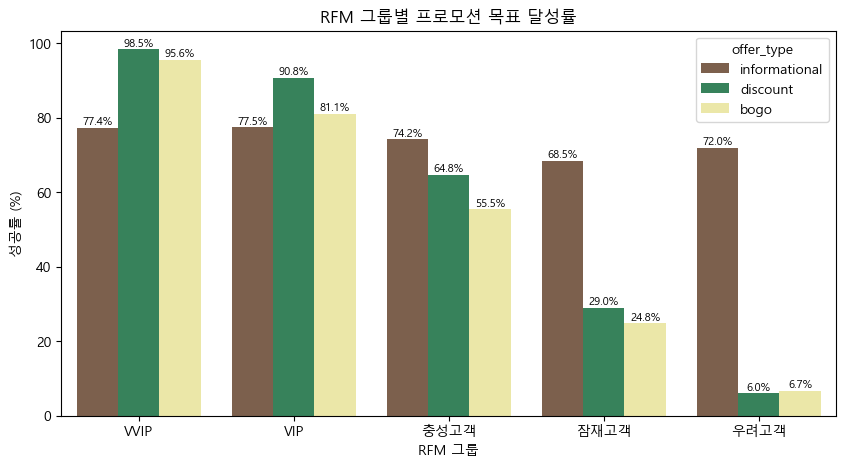

In [82]:
# 완료율 기준 내림차순 정렬
palette = ["#845f45", '#2a8f5a', "#f6f19d"]
           
# 그래프 그리기
fig, ax = plt.subplots(figsize=(10,5))
sns.barplot(
    data=rfm_completion,
    x='RFM_group',
    y='completion_rate_pct',
    palette=palette,
    ax=ax,
    hue='offer_type'
)

# 막대 위에 완료율 라벨 표시
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # 높이가 0 이상일 때만 라벨 표시
        ax.text(
            x=p.get_x() + p.get_width()/2,
            y=height,
            s=f"{height:.1f}%",
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.title('RFM 그룹별 프로모션 목표 달성률')
plt.xlabel('RFM 그룹')
plt.ylabel('성공률 (%)')
plt.show()

<!-- - 보상 민감도 = 보상(Reward) / 지출 조건(difficulty) -->

### 지출 조건에 따른 그룹별 완료율
- 최소 지출 조건이 가장 낮다고 완료율이 가장 높지 않음. 7달러 지출조건은 보상 또한 낮은편
- 우려 고객의 경우 최소 지출조건이 높아지면 최대 3배 이상의 완료율 차이를 보임 → 우려 고객에게는 가성비의 프로모션이 효과적

In [83]:
# 1. 오퍼 수신(received), 확인(viewed), 완료(completed) 데이터 추출
received = df_total[(df_total['event'] == 'offer received')]
viewed = df_total[(df_total['event'] == 'offer viewed') & (df_total['difficulty'] == 0)]
completed = df_total[(df_total['event'] == 'offer completed') & (df_total['difficulty'] > 0)]

# 2. 그룹간 난이도별 수신 횟수 계산
received_counts = received.groupby(['RFM_group', 'difficulty']).size().reset_index(name='received_cnt')

# 3. 그룹간 난이도별 확인 횟수 계산
viewed_counts = (viewed.groupby(['RFM_group', 'difficulty']).size().reset_index(name='viewed_cnt'))

# 3. 그룹간 난이도별 완료 횟수 계산
completed_counts = completed.groupby(['RFM_group', 'difficulty']).size().reset_index(name='completed_cnt')

# 4. 두 데이터 병합 및 완료율 계산
# conversion_df = pd.merge(received_counts, completed_counts, on=['RFM_group', 'difficulty'], how='left')
# conversion_df['completed_cnt'] = conversion_df['completed_cnt'].fillna(0) # 완료 기록 없는 경우 0처리
conversion_df = received_counts \
    .merge(viewed_counts, on=['RFM_group', 'difficulty'], how='left') \
    .merge(completed_counts, on=['RFM_group', 'difficulty'], how='left')

conversion_df[['viewed_cnt', 'completed_cnt']] = conversion_df[['viewed_cnt', 'completed_cnt']].fillna(0)

# 5. 목표 달성률 계산
conversion_df['success_rate'] = conversion_df.apply(
    lambda r: (
        (r['viewed_cnt'] / r['received_cnt']) * 100
        if r['difficulty'] == 0
        else (r['completed_cnt'] / r['received_cnt']) * 100
    ),
    axis=1
)

# 결과 확인 (정렬)
rfm_order = ['VVIP', 'VIP', '충성고객', '잠재고객', '우려고객']

conversion_df['RFM_group'] = pd.Categorical(
    conversion_df['RFM_group'],
    categories=rfm_order,
    ordered=True
)

conversion_df = conversion_df.sort_values(['RFM_group', 'difficulty'])
conversion_df

,RFM_group,difficulty,received_cnt,viewed_cnt,completed_cnt,success_rate
5,VVIP,0.0,630,469.0,0.0,74.444444
6,VVIP,5.0,724,0.0,693.0,95.718232
7,VVIP,7.0,473,0.0,470.0,99.365751
8,VVIP,10.0,1693,0.0,1619.0,95.629061
9,VVIP,20.0,312,0.0,297.0,95.192308
0,VIP,0.0,4070,3071.0,0.0,75.454545
1,VIP,5.0,4460,0.0,3799.0,85.179372
2,VIP,7.0,2381,0.0,2272.0,95.422092
3,VIP,10.0,9258,0.0,7516.0,81.183841
4,VIP,20.0,2168,0.0,1676.0,77.306273


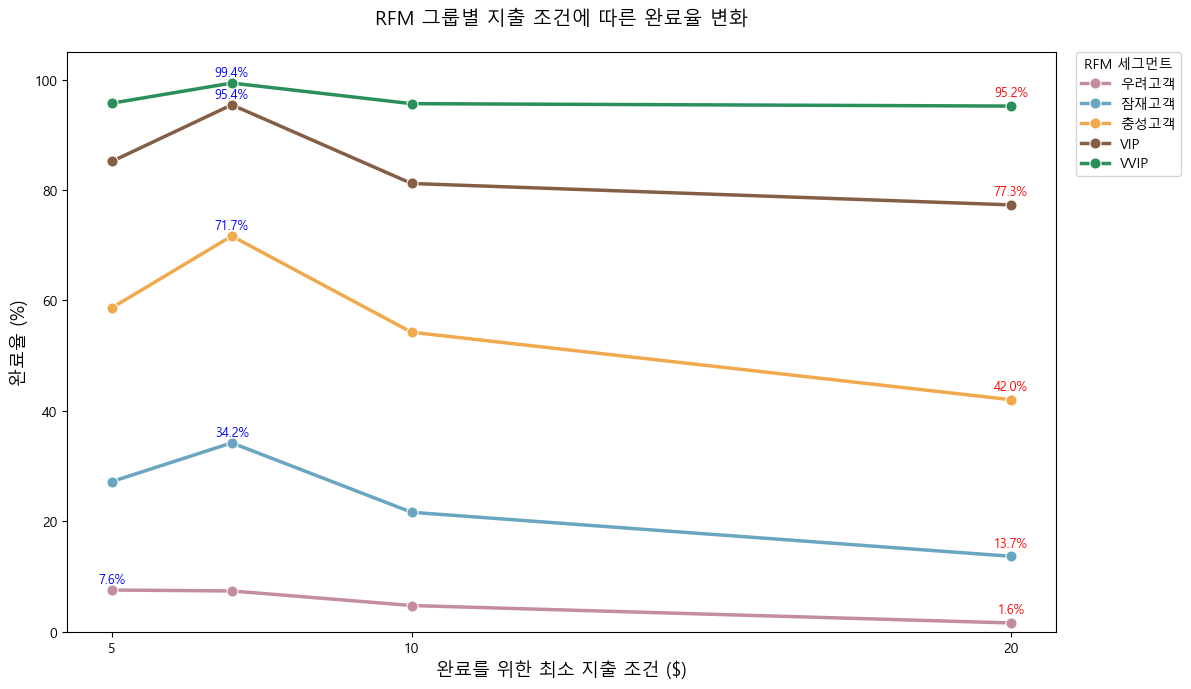

In [84]:
# difficulty > 0 데이터만 사용
plot_df = conversion_df[conversion_df['difficulty'] > 0]

palette2 = {
    'VVIP': '#2a8f5a',   # 스타벅스 연두
    'VIP': '#845f45',    # 스타벅스 갈색
    '충성고객': '#f1a94e', # 연한 베이지
    '잠재고객': '#6aa6c1', # 연두 톤 추가
    '우려고객': '#c48d9f'   # 연한 갈색 톤
}

plt.figure(figsize=(12, 7))
ax = sns.lineplot(
    data=plot_df,
    x='difficulty', 
    y='success_rate', 
    hue='RFM_group',
    palette=palette2, 
    hue_order=order,
    marker='o', 
    markersize=8,
    linewidth=2.5
)

# --- [추가] 각 그룹별 최댓값/최솟값 텍스트 표기 로직 ---
for group in order:
    # 해당 그룹 데이터만 필터링
    group_data = plot_df[plot_df['RFM_group'] == group]
    
    if not group_data.empty:
        # 최댓값과 최솟값 지점 찾기
        max_row = group_data.loc[group_data['success_rate'].idxmax()]
        min_row = group_data.loc[group_data['success_rate'].idxmin()]
        
        # 최댓값 표기
        ax.annotate(f'{max_row["success_rate"]:.1f}%', 
                    xy=(max_row['difficulty'], max_row['success_rate']),
                    xytext=(0, 5), textcoords='offset points',
                    ha='center', fontsize=9, color='blue')
        
        # 최솟값 표기 (최댓값과 최솟값이 같은 지점이 아닐 때만)
        if max_row['difficulty'] != min_row['difficulty']:
            ax.annotate(f'{min_row["success_rate"]:.1f}%', 
                        xy=(min_row['difficulty'], min_row['success_rate']),
                        xytext=(0, 7), textcoords='offset points',
                        ha='center', fontsize=9, color='red')
# ----------------------------------------------------

# 4. 그래프 디테일 설정
plt.title('RFM 그룹별 지출 조건에 따른 완료율 변화', fontsize=14, pad=20)
plt.xlabel('완료를 위한 최소 지출 조건 ($)', fontsize=13)
plt.ylabel('완료율 (%)', fontsize=13)
plt.xticks([5, 10, 20]) # 데이터에 존재하는 difficulty 지점 강조
plt.ylim(0, 105)

# 5. 범례 위치 조정
plt.legend(title='RFM 세그먼트', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()

### 고객 그룹간 소득 구간별 평균 소비 금액과 그룹간 소득구간 구성비

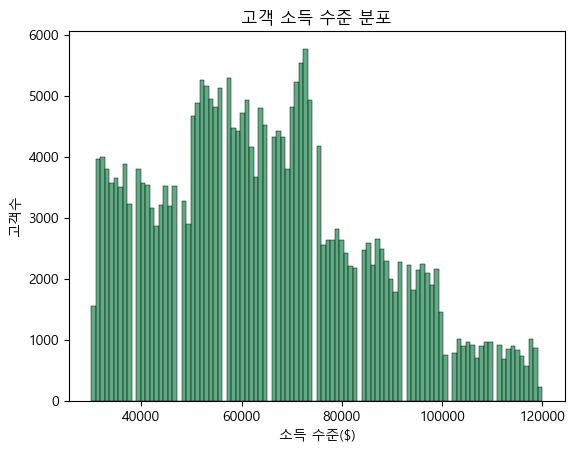

In [85]:
# 소득구간 분포 확인
sns.histplot(df_total['income'], color='#2a8f5a')
plt.title('고객 소득 수준 분포')
plt.xlabel('소득 수준($)')
plt.ylabel('고객수')
plt.show()

In [86]:
# 소득구간 범주화
df_total['income_group'] = np.select(
    [
        df_total['income'] <= 50000,
        df_total['income'] <= 100000
    ],
    ['low', 'middle'], default='high'
)

In [87]:
income_df = df_total.groupby(['RFM_group', 'income_group'])['amount'].mean().reset_index()
income_df

,RFM_group,income_group,amount
0,VIP,high,23.975301
1,VIP,low,8.047187
2,VIP,middle,15.934499
3,VVIP,high,26.587208
4,VVIP,low,10.150981
5,VVIP,middle,17.790992
6,우려고객,high,3.626927
7,우려고객,low,3.706071
8,우려고객,middle,10.172690
9,잠재고객,high,5.928272


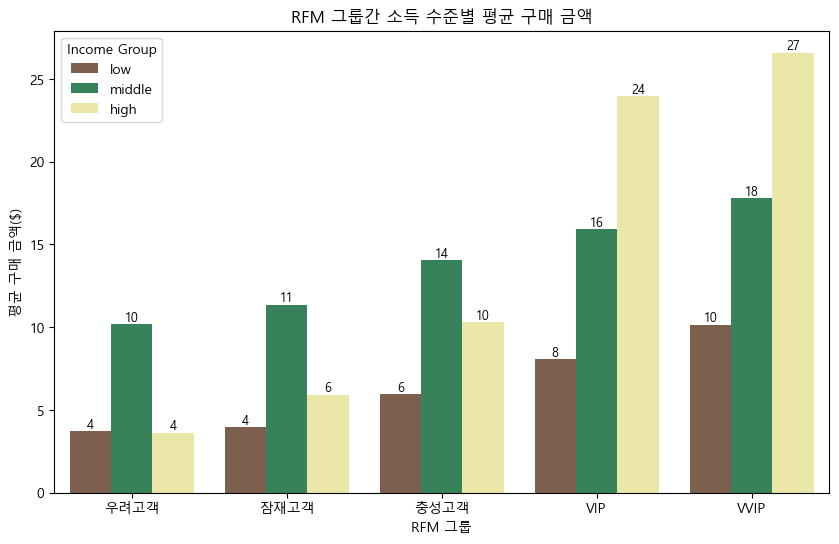

In [88]:
income_order = ['low', 'middle', 'high']

fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(
    data=income_df,
    x='RFM_group',
    y='amount',
    hue='income_group',
    palette=palette,
    order=order,
    hue_order=income_order,
    ax=ax
)

# 막대 위에 텍스트 표시
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # 0값은 제외
        ax.text(
            x=p.get_x() + p.get_width()/2,
            y=height,
            s=f"{height:,.0f}",   # 천 단위 콤마
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.title('RFM 그룹간 소득 수준별 평균 구매 금액')
plt.xlabel('RFM 그룹')
plt.ylabel('평균 구매 금액($)')
plt.legend(title='Income Group')
plt.show()

In [89]:
income_df1 = df_total.groupby(['RFM_group', 'income_group'])['amount'].count().reset_index()

In [90]:
income_df1

,RFM_group,income_group,amount
0,VIP,high,3843
1,VIP,low,14979
2,VIP,middle,36091
3,VVIP,high,462
4,VVIP,low,3169
5,VVIP,middle,9150
6,우려고객,high,755
7,우려고객,low,621
8,우려고객,middle,658
9,잠재고객,high,4507


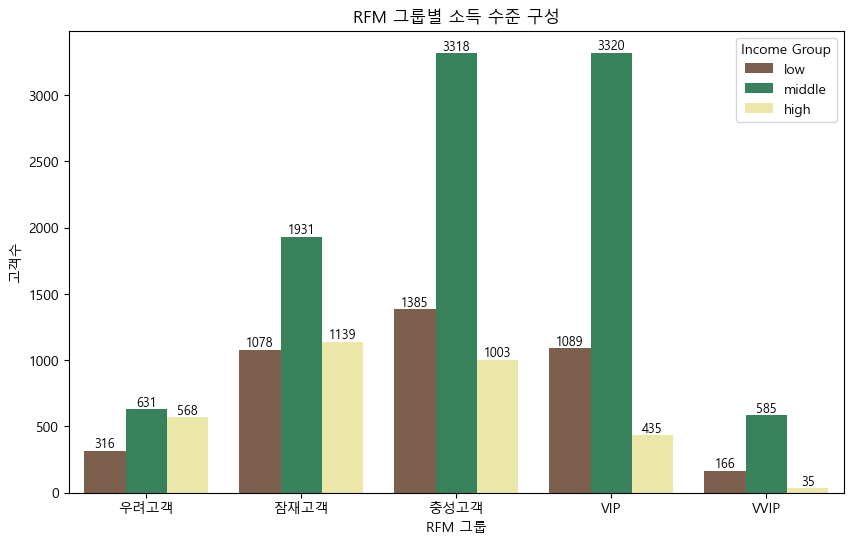

In [91]:
income_df1 = (
    df_total
    .groupby(['RFM_group', 'income_group'])['person_id']
    .nunique()
    .reset_index(name='customer_cnt')
)

# RFM_group별 전체 고객 수
total_cnt = (
    income_df1
    .groupby('RFM_group')['customer_cnt']
    .transform('sum')
)

# 비율 컬럼 추가
income_df1['ratio'] = income_df1['customer_cnt'] / total_cnt * 100

fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(
    data=income_df1,
    x='RFM_group',
    y='customer_cnt',
    hue='income_group',
    palette=palette,
    order=order,
    hue_order=income_order,
    ax=ax
)

# seaborn bar 순서에 맞게 ratio 리스트 생성
counts = []
for income in income_order:
    for rfm in order:
        value = income_df1.loc[
            (income_df1['RFM_group'] == rfm) & 
            (income_df1['income_group'] == income),
            'customer_cnt'
        ]
        counts.append(value.values[0] if len(value) > 0 else 0)

# 막대 위에 customer_cnt 표시
for p, count in zip(ax.patches, counts):
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width()/2,
            height,
            f"{int(count)}",  # 정수로 표시
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.title('RFM 그룹별 소득 수준 구성')
plt.xlabel('RFM 그룹')
plt.ylabel('고객수')
plt.legend(title='Income Group')
plt.show()

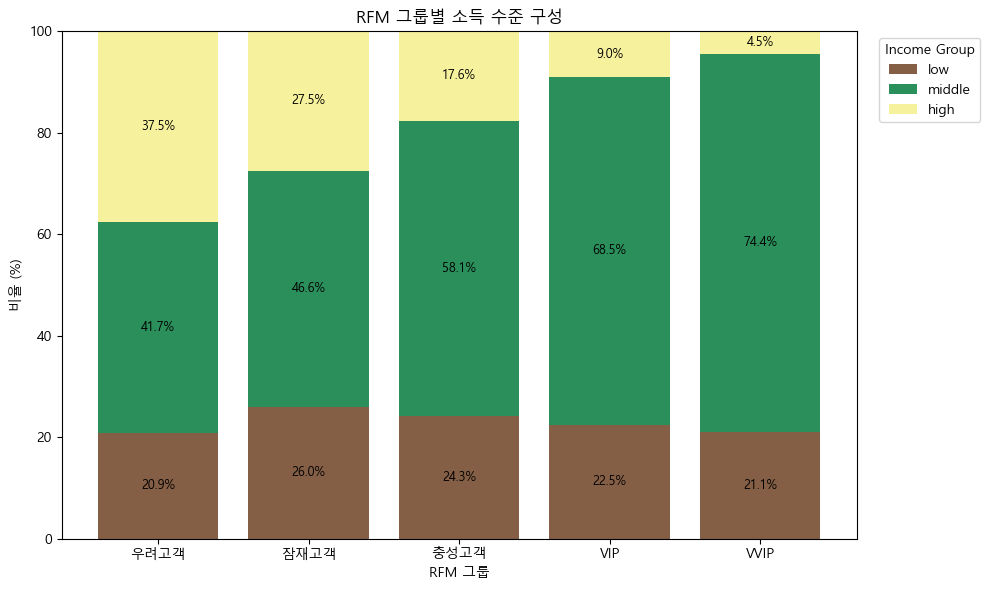

In [92]:
# RFM 그룹 순서
rfm_order = order  # ['VVIP', 'VIP', '충성고객', '잠재고객', '우려고객']

# Income 그룹 순서
income_order = income_order  # 기존 사용하던 순서

# palette: income_group별 색상
palette3 = {
    'low': '#845f45',     # 눈에 띄는 오렌지
    'middle': '#2a8f5a',  # 파랑/하늘색
    'high': '#f6f19d'     # 연한 보라/핑크
}

# figure 설정
fig, ax = plt.subplots(figsize=(10,6))

# 누적 막대 그리기
bottom = np.zeros(len(rfm_order))  # 누적 시작점
for income in income_order:
    values = []
    for rfm in rfm_order:
        ratio = income_df1.loc[
            (income_df1['RFM_group'] == rfm) & 
            (income_df1['income_group'] == income),
            'ratio'
        ]
        values.append(ratio.values[0] if len(ratio) > 0 else 0)
    ax.bar(rfm_order, values, bottom=bottom, color=palette3[income], label=income)
    bottom += values  # 다음 누적 위치

# 막대 위에 비율 표시
bottom = np.zeros(len(rfm_order))
for income in income_order:
    values = []
    for i, rfm in enumerate(rfm_order):
        ratio = income_df1.loc[
            (income_df1['RFM_group'] == rfm) & 
            (income_df1['income_group'] == income),
            'ratio'
        ]
        val = ratio.values[0] if len(ratio) > 0 else 0
        values.append(val)
        if val > 0:
            ax.text(
                i,
                bottom[i] + val/2,  # 누적 막대 중간 위치
                f"{val:.1f}%",
                ha='center',
                va='center',
                fontsize=9,
                color='black'  # 막대가 진하면 흰색 글씨 추천
            )
        bottom[i] += val

# y축 0~100%
ax.set_ylim(0, 100)
ax.set_ylabel('비율 (%)')
ax.set_xlabel('RFM 그룹')
plt.title('RFM 그룹별 소득 수준 구성')
plt.legend(title='Income Group', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()
